In [1]:
import numpy as np
from scipy . optimize import minimize
import os
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.cm import get_cmap
from pprint import pprint
from scipy.interpolate import griddata


In [19]:
np.random.seed(2025)
n, p = 200, 2
X = np.random.randn(n, p)
true_w = np.array([2.0, -3.0])
logits = X @ true_w
prob = 1 / (1 + np.exp(-logits))
y = (np.random.rand(n) < prob).astype(float)





In [20]:


def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def softplus(t):
    out = np.empty_like(t)
    big = t > 0
    out[big] = t[big] + np.log1p(np.exp(-t[big]))
    out[~big] = np.log1p(np.exp(t[~big]))
    return out

def f(w, X, y):
    z = X @ w
    return np.mean(softplus(z) - y * z)

def grad(w, X, y):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

def hess(w, X, y):
    z = X @ w
    S = sigmoid(z) * (1.0 - sigmoid(z))
    return (X.T * S) @ X / len(y)

def gradient_descent_logistic(X, y, stepsize=0.2, epsilon=1e-6, max_iters=20000):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'w': []}
    for _ in range(max_iters):
        g = grad(w, X, y)
        w_new = w - stepsize * g
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['w'].append(w.copy())
        if np.linalg.norm(w_new - w) <= epsilon * max(1.0, np.linalg.norm(w)):
            w = w_new
            break
        w = w_new
    history['w'].append(w.copy())
    return w, history

def newton_method(X, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'step': [], 'w': [], 'direction': []}
    
    for _ in range(T):
        g = grad(w, X, y)
        H = hess(w, X, y)
        if reg > 0:
            H = H + reg * np.eye(X.shape[1])
        try:
            s = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            H = H + 1e-6 * np.eye(X.shape[1])
            s = np.linalg.solve(H, -g)

        t = 1.0
        f_curr = f(w, X, y)

        while True:
            w_try = w + t * s
            if f(w_try, X, y) <= f_curr + alpha * t * g.dot(s):
                break
            t *= beta
            if t < 1e-12:
                break

        w = w + t * s
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['step'].append(t)
        history['w'].append(w.copy())
        history['direction'].append(s.copy())

        if np.linalg.norm(g) < tol:
            break

    return w, history

# Fit with Gradient Descent
w_gd, hist_gd = gradient_descent_logistic(X, y, stepsize=0.2)

# Fit with Newton's Method
w_newton, hist_newton = newton_method(X, y)

# BFGS
w0 = np.zeros(X.shape[1])
bfgs_w_history = [w0.copy()]
bfgs_obj_history = []
bfgs_gradnorm_history = []

def bfgs_callback(w):
    bfgs_w_history.append(w.copy())
    bfgs_obj_history.append(f(w, X, y))
    bfgs_gradnorm_history.append(np.linalg.norm(grad(w, X, y)))

def scipy_obj(w):
    return f(w, X, y)

def scipy_grad(w):
    return grad(w, X, y)

res_bfgs = minimize(scipy_obj, np.zeros(X.shape[1]), jac=scipy_grad, method='BFGS', 
                    callback=bfgs_callback, options={'disp': True})

w_bfgs = res_bfgs.x

def decision_boundary(w, X, label, color):
    x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
    x2_vals = -(w[0] / w[1]) * x1_vals
    line, = plt.plot(x1_vals, x2_vals, color=color, label=label, linewidth=2)
    return line 

Optimization terminated successfully.
         Current function value: 0.229718
         Iterations: 15
         Function evaluations: 16
         Gradient evaluations: 16


In [73]:
#estimated weight vectors
print("GD w:", w_gd)
print("Newton w:", w_newton)
print("BFGS w:", w_bfgs)
print("True w:", true_w)

GD w: [ 2.70899588 -4.20292781]
Newton w: [ 2.7104343  -4.20535123]
BFGS w: [ 2.7104343  -4.20535123]
True w: [ 2. -3.]


In [74]:
def compute_slope(w):
    return -w[0] / w[1]

def compute_intercept(w):
    return 0.0

slope_true   = compute_slope(true_w)
slope_gd     = compute_slope(w_gd)
slope_newton = compute_slope(w_newton)
slope_bfgs   = compute_slope(w_bfgs)

inter_true   = compute_intercept(true_w)
inter_gd     = compute_intercept(w_gd)
inter_newton = compute_intercept(w_newton)
inter_bfgs   = compute_intercept(w_bfgs)

print("Slopes:")
print(" True:   ", slope_true)
print(" GD:     ", slope_gd)
print(" Newton: ", slope_newton)
print(" BFGS:   ", slope_bfgs)

print("\nIntercepts (all models have no bias term):")
print(" True:   ", inter_true)
print(" GD:     ", inter_gd)
print(" Newton: ", inter_newton)
print(" BFGS:   ", inter_bfgs)


Slopes:
 True:    0.6666666666666666
 GD:      0.6445497053325736
 Newton:  0.6445203146170699
 BFGS:    0.6445203148261778

Intercepts (all models have no bias term):
 True:    0.0
 GD:      0.0
 Newton:  0.0
 BFGS:    0.0


BFGS update directions (first 3):
d_BFGS[0] = [ 0.24010386 -0.27976868]
d_BFGS[1] = [ 0.53383507 -0.65991337]
d_BFGS[2] = [ 0.52573721 -0.70015258]

Newton update directions (first 3):
d_newton[0] = [ 0.94177209 -1.36137533]
d_newton[1] = [ 0.65475906 -1.03503617]
d_newton[2] = [ 0.60641319 -0.98338439]


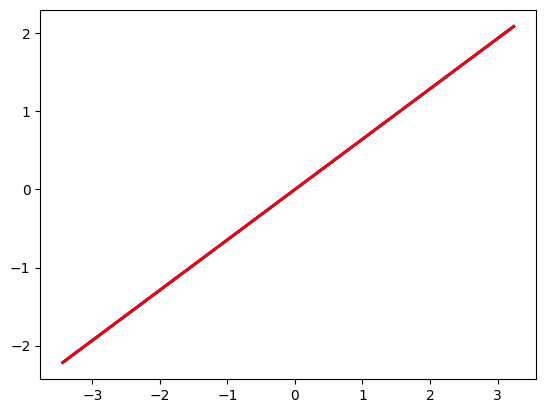

In [21]:
# Decision boundaries (straight lines)
decision_gd = decision_boundary(w_gd, X, "Gradient Descent", "g")
decision_newton = decision_boundary(w_newton, X, "Newton's Method", "b")
decision_bfgs = decision_boundary(w_bfgs, X, "BFGS", "r")

def compute_slope(w):
    return -w[0] / w[1]

def compute_intercept(w):
    return 0.0

slope_true = compute_slope(true_w)
slope_gd = compute_slope(w_gd)
slope_newton = compute_slope(w_newton)
slope_bfgs = compute_slope(w_bfgs)

inter_true = compute_intercept(true_w)
inter_gd = compute_intercept(w_gd)
inter_newton = compute_intercept(w_newton)
inter_bfgs = compute_intercept(w_bfgs)

# Angles between decision boundaries
def decision_angle(w, wtrue):
    m1 = compute_slope(w)
    m2 = compute_slope(wtrue)
    numerator = abs(m1 - m2)
    denominator = abs(1 + (m1 * m2))
    theta_rad = np.arctan(numerator / denominator)
    return np.degrees(theta_rad)

angle_gd = decision_angle(w_gd, true_w)
angle_newton = decision_angle(w_newton, true_w)
angle_bfgs = decision_angle(w_bfgs, true_w)

# First 3 BFGS iterates
w_bfgs_list = bfgs_w_history
bfgs_directions = []
for k in range(3):
    d_bfgs = w_bfgs_list[k+1] - w_bfgs_list[k]
    bfgs_directions.append(d_bfgs)
    
print("BFGS update directions (first 3):")
for i, d_bfgs in enumerate(bfgs_directions):
    print(f"d_BFGS[{i}] =", d_bfgs)
    
w0_newton = np.zeros(X.shape[1])
w_newton_list = [w0_newton] + hist_newton['w']
newton_directions = []
for k in range(3):
    d_newton = w_newton_list[k+1] - w_newton_list[k]
    newton_directions.append(d_newton)
    
print("\nNewton update directions (first 3):")
for i, d_newton in enumerate(newton_directions):
    print(f"d_newton[{i}] =", d_newton)


=== eps = 100 ===
GD iterations:      20000
Newton iterations:  6
BFGS iterations:    10

=== eps = 10 ===
GD iterations:      20000
Newton iterations:  6
BFGS iterations:    9

=== eps = 1 ===
GD iterations:      683
Newton iterations:  6
BFGS iterations:    11

=== eps = 0.1 ===
GD iterations:      20000
Newton iterations:  6
BFGS iterations:    19

=== eps = 0.01 ===
GD iterations:      20000
Newton iterations:  6
BFGS iterations:    24

=== eps = 0.001 ===
GD iterations:      207
Newton iterations:  8
BFGS iterations:    6

=== eps = 0.0001 ===
GD iterations:      202
Newton iterations:  50
BFGS iterations:    6


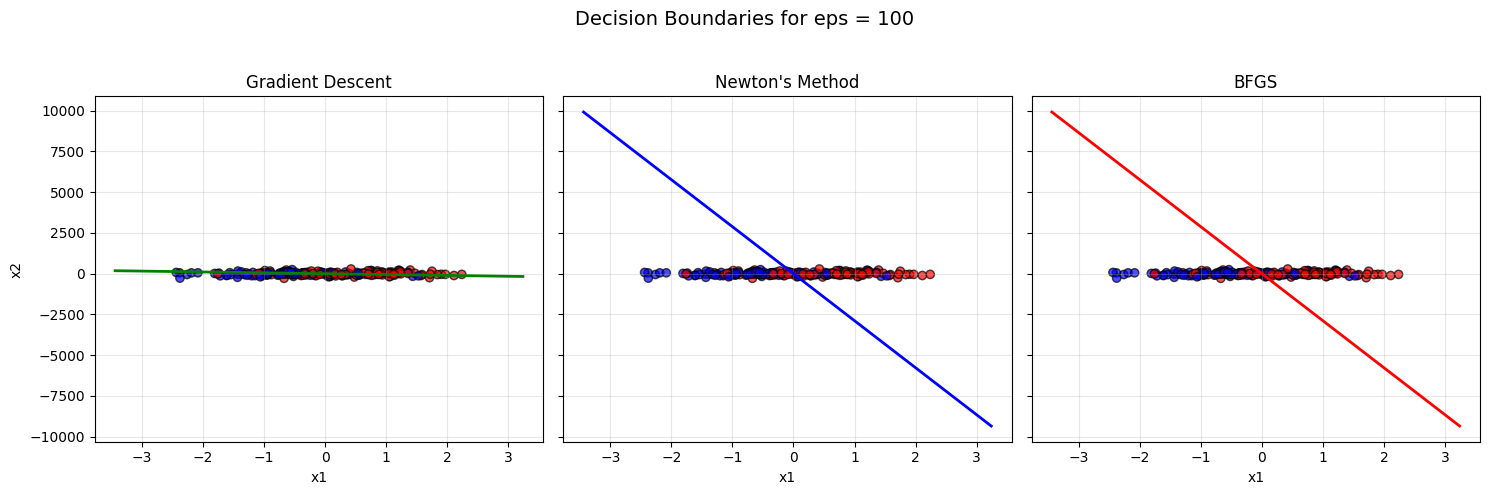

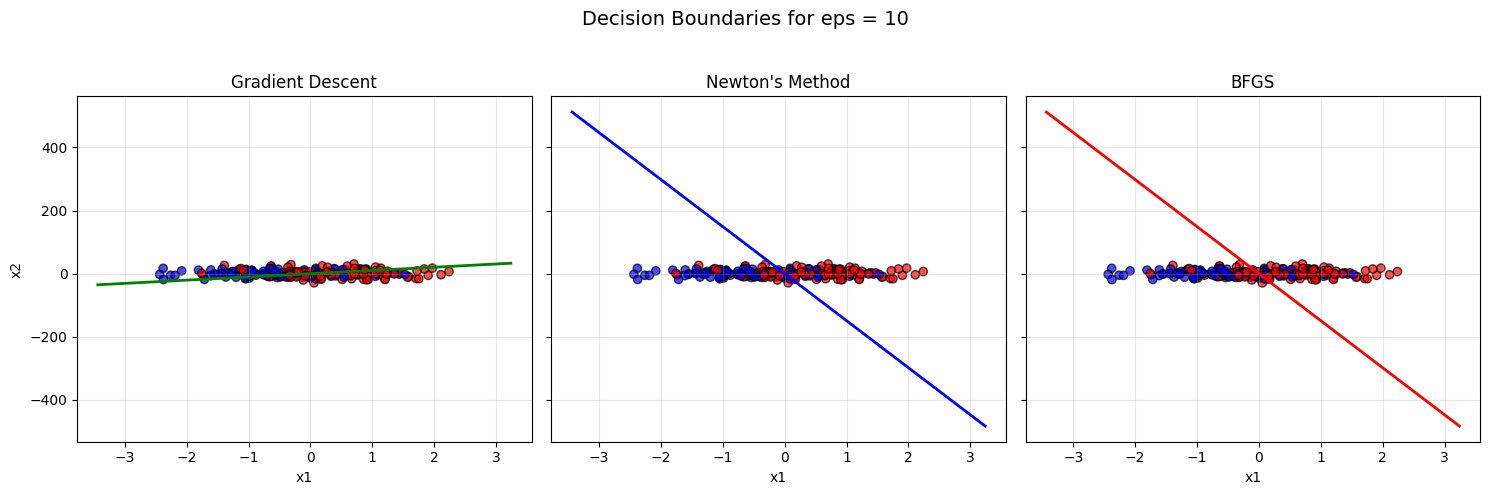

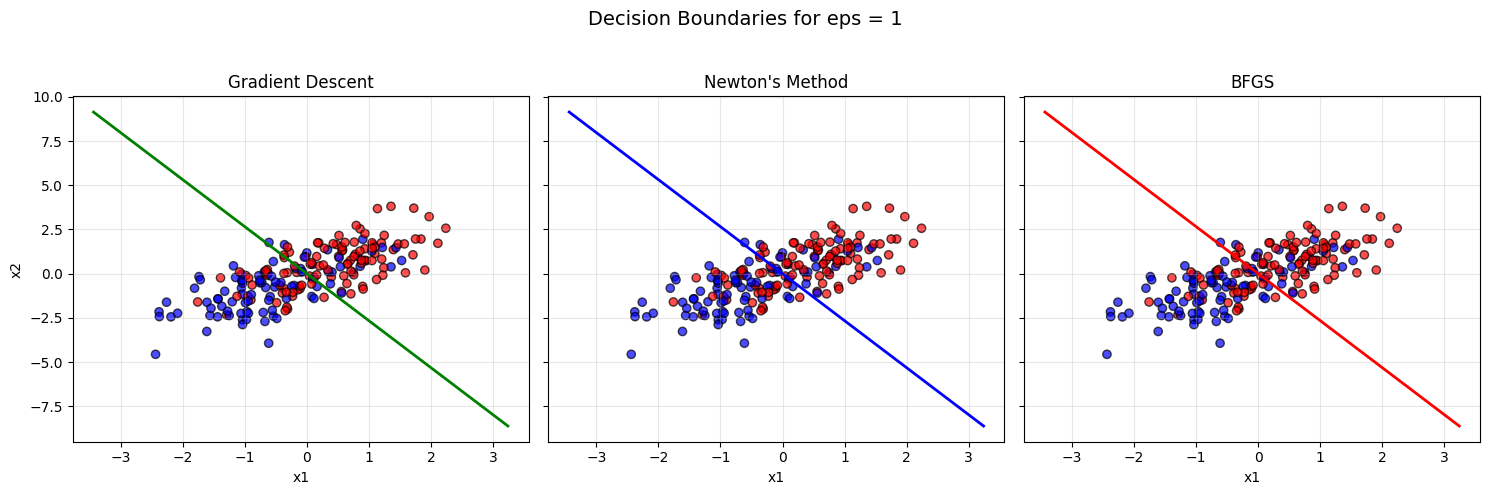

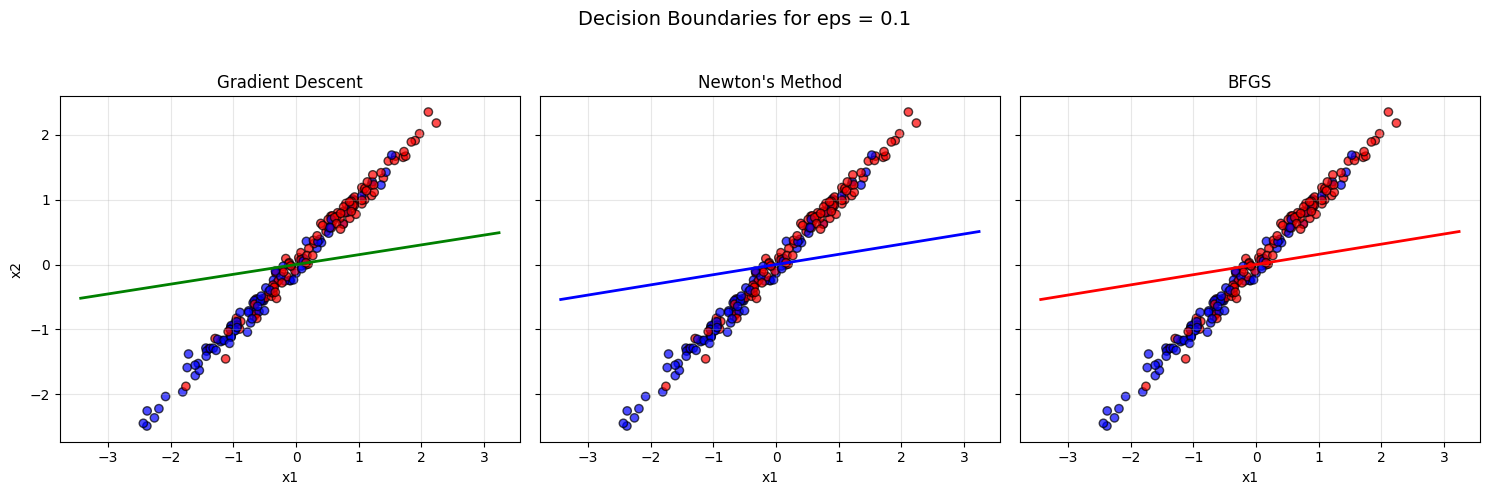

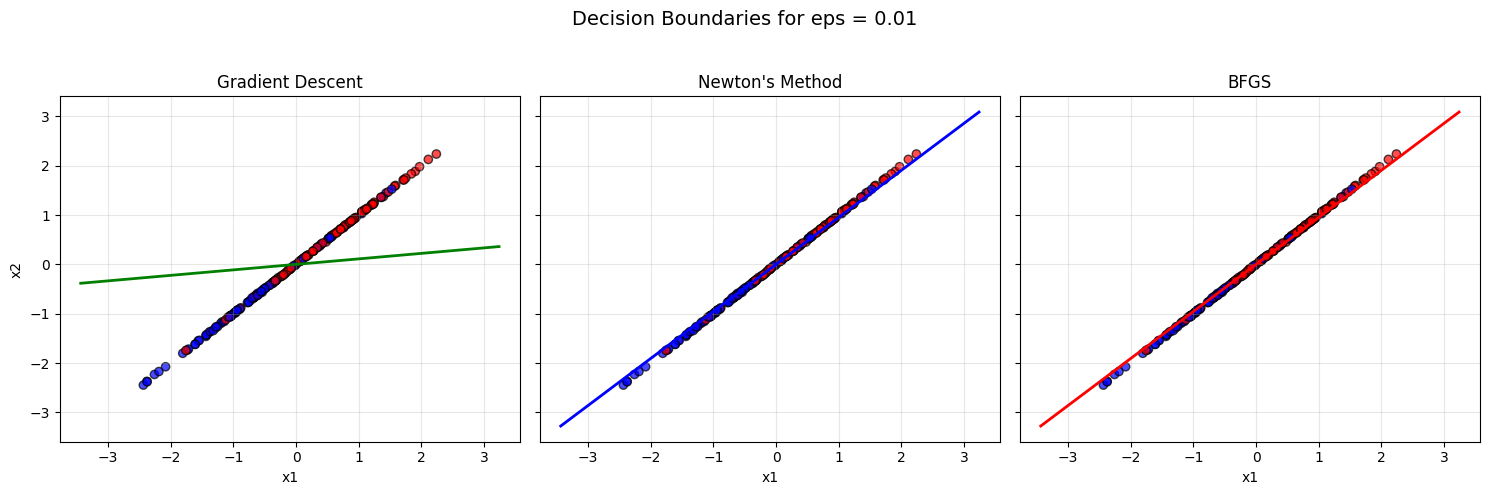

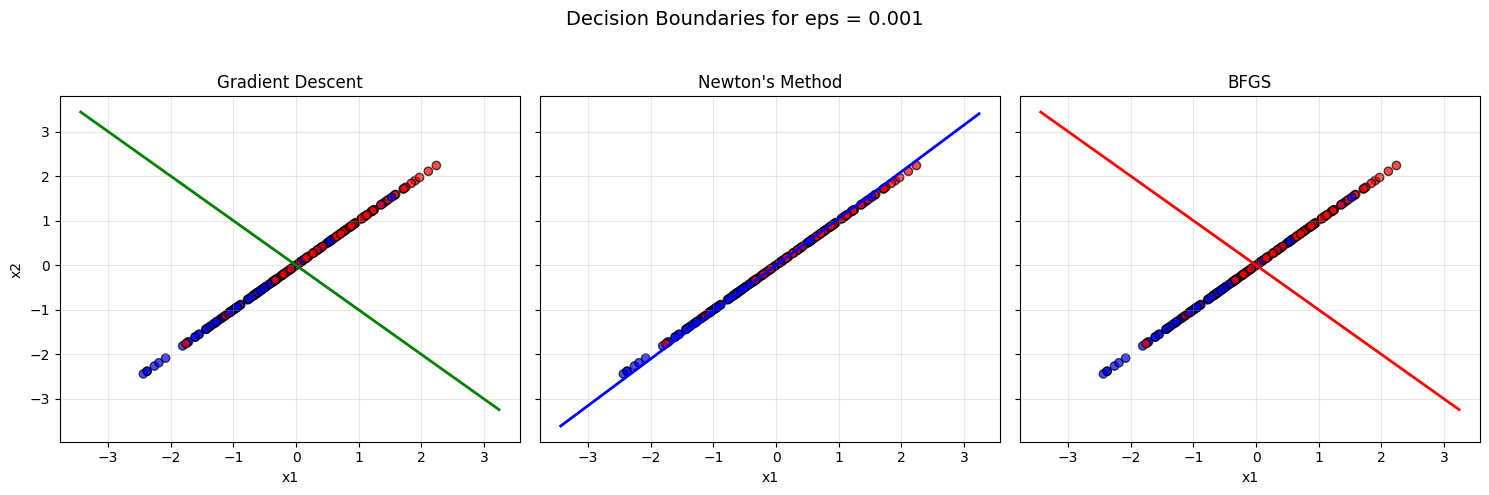

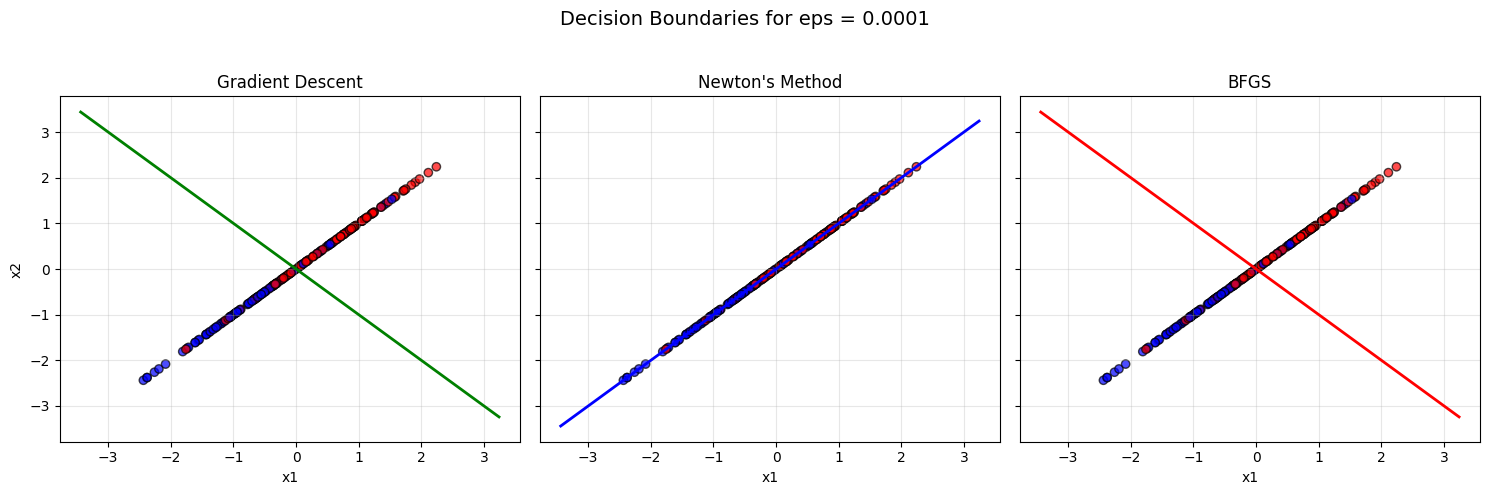

In [23]:


# Make X nearly collinear: x2 ≈ x1
eps_list = [100, 10, 1, 1e-1, 1e-2, 1e-3, 1e-4]

results_collinear = {}

for eps in eps_list:
    X_col = np.copy(X)
    X_col[:, 1] = X_col[:, 0] + eps * np.random.randn(n)
    
    w_gd_col, hist_gd_col = gradient_descent_logistic(X_col, y, stepsize=0.2, epsilon=1e-6, max_iters=20000)
    
    w_newton_col, hist_newton_col = newton_method(X_col, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0)
    
    bfgs_w_history = []
    bfgs_obj_history = []
    bfgs_grad_history = []

    def bfgs_callback(w):
        bfgs_w_history.append(w.copy())
        bfgs_obj_history.append(f(w, X_col, y))
        bfgs_grad_history.append(np.linalg.norm(grad(w, X_col, y)))

    def scipy_obj_col(w):
        return f(w, X_col, y)

    def scipy_grad_col(w):
        return grad(w, X_col, y)

    res_bfgs_col = minimize(scipy_obj_col, np.zeros(X_col.shape[1]), jac=scipy_grad_col, method="BFGS", 
                            callback=bfgs_callback, options={"disp": False})
    w_bfgs_col = res_bfgs_col.x
    
    results_collinear[eps] = {
        "X_col": X_col, 
        "w_gd": w_gd_col, 
        "hist_gd": hist_gd_col, 
        "w_newton": w_newton_col,
        "hist_newton": hist_newton_col, 
        "w_bfgs": w_bfgs_col, 
        "bfgs_w_history": bfgs_w_history, 
        "bfgs_obj_history": bfgs_obj_history, 
        "bfgs_grad_history": bfgs_grad_history,
    }
    
    print(f"\n=== eps = {eps} ===")
    print("GD iterations:     ", len(hist_gd_col['obj']))
    print("Newton iterations: ", len(hist_newton_col['obj']))
    print("BFGS iterations:   ", len(bfgs_obj_history))
    
# Plot decision boundaries for collinear data
def decision_line(w, x_range):
    return - (w[0] / w[1]) * x_range

# Plot 3 subplots for each epsilon
for eps in eps_list:
    res = results_collinear[eps]
    X_col = res["X_col"]

    w_gd = res["w_gd"]
    w_newton = res["w_newton"]
    w_bfgs = res["w_bfgs"]

    x_min, x_max = X_col[:,0].min() - 1, X_col[:,0].max() + 1
    x_range = np.linspace(x_min, x_max, 300)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.suptitle(f"Decision Boundaries for eps = {eps}", fontsize=14)

    # Gradient Descent subplot
    ax = axes[0]
    ax.scatter(X_col[:,0], X_col[:,1], c=y, cmap="bwr", alpha=0.7, edgecolor="k")
    ax.plot(x_range, decision_line(w_gd, x_range), "g", linewidth=2)
    ax.set_title("Gradient Descent")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(alpha=0.3)

    # Newton subplot
    ax = axes[1]
    ax.scatter(X_col[:,0], X_col[:,1], c=y, cmap="bwr", alpha=0.7, edgecolor="k")
    ax.plot(x_range, decision_line(w_newton, x_range), "b", linewidth=2)
    ax.set_title("Newton's Method")
    ax.set_xlabel("x1")
    ax.grid(alpha=0.3)

    # BFGS subplot
    ax = axes[2]
    ax.scatter(X_col[:,0], X_col[:,1], c=y, cmap="bwr", alpha=0.7, edgecolor="k")
    ax.plot(x_range, decision_line(w_bfgs, x_range), "r", linewidth=2)
    ax.set_title("BFGS")
    ax.set_xlabel("x1")
    ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

BFGS update directions (first 3):
d_BFGS[0] = [ 0.53383507 -0.65991337]
d_BFGS[1] = [ 0.52573721 -0.70015258]
d_BFGS[2] = [ 0.46778427 -0.66811921]

Newton update directions (first 3):
d_newton[0] = [ 0.94177209 -1.36137533]
d_newton[1] = [ 0.65475906 -1.03503617]
d_newton[2] = [ 0.60641319 -0.98338439]

=== eps = 100 ===

=== eps = 10 ===

=== eps = 1 ===

=== eps = 0.1 ===

=== eps = 0.01 ===

=== eps = 0.001 ===

=== eps = 0.0001 ===

DONE ✔️


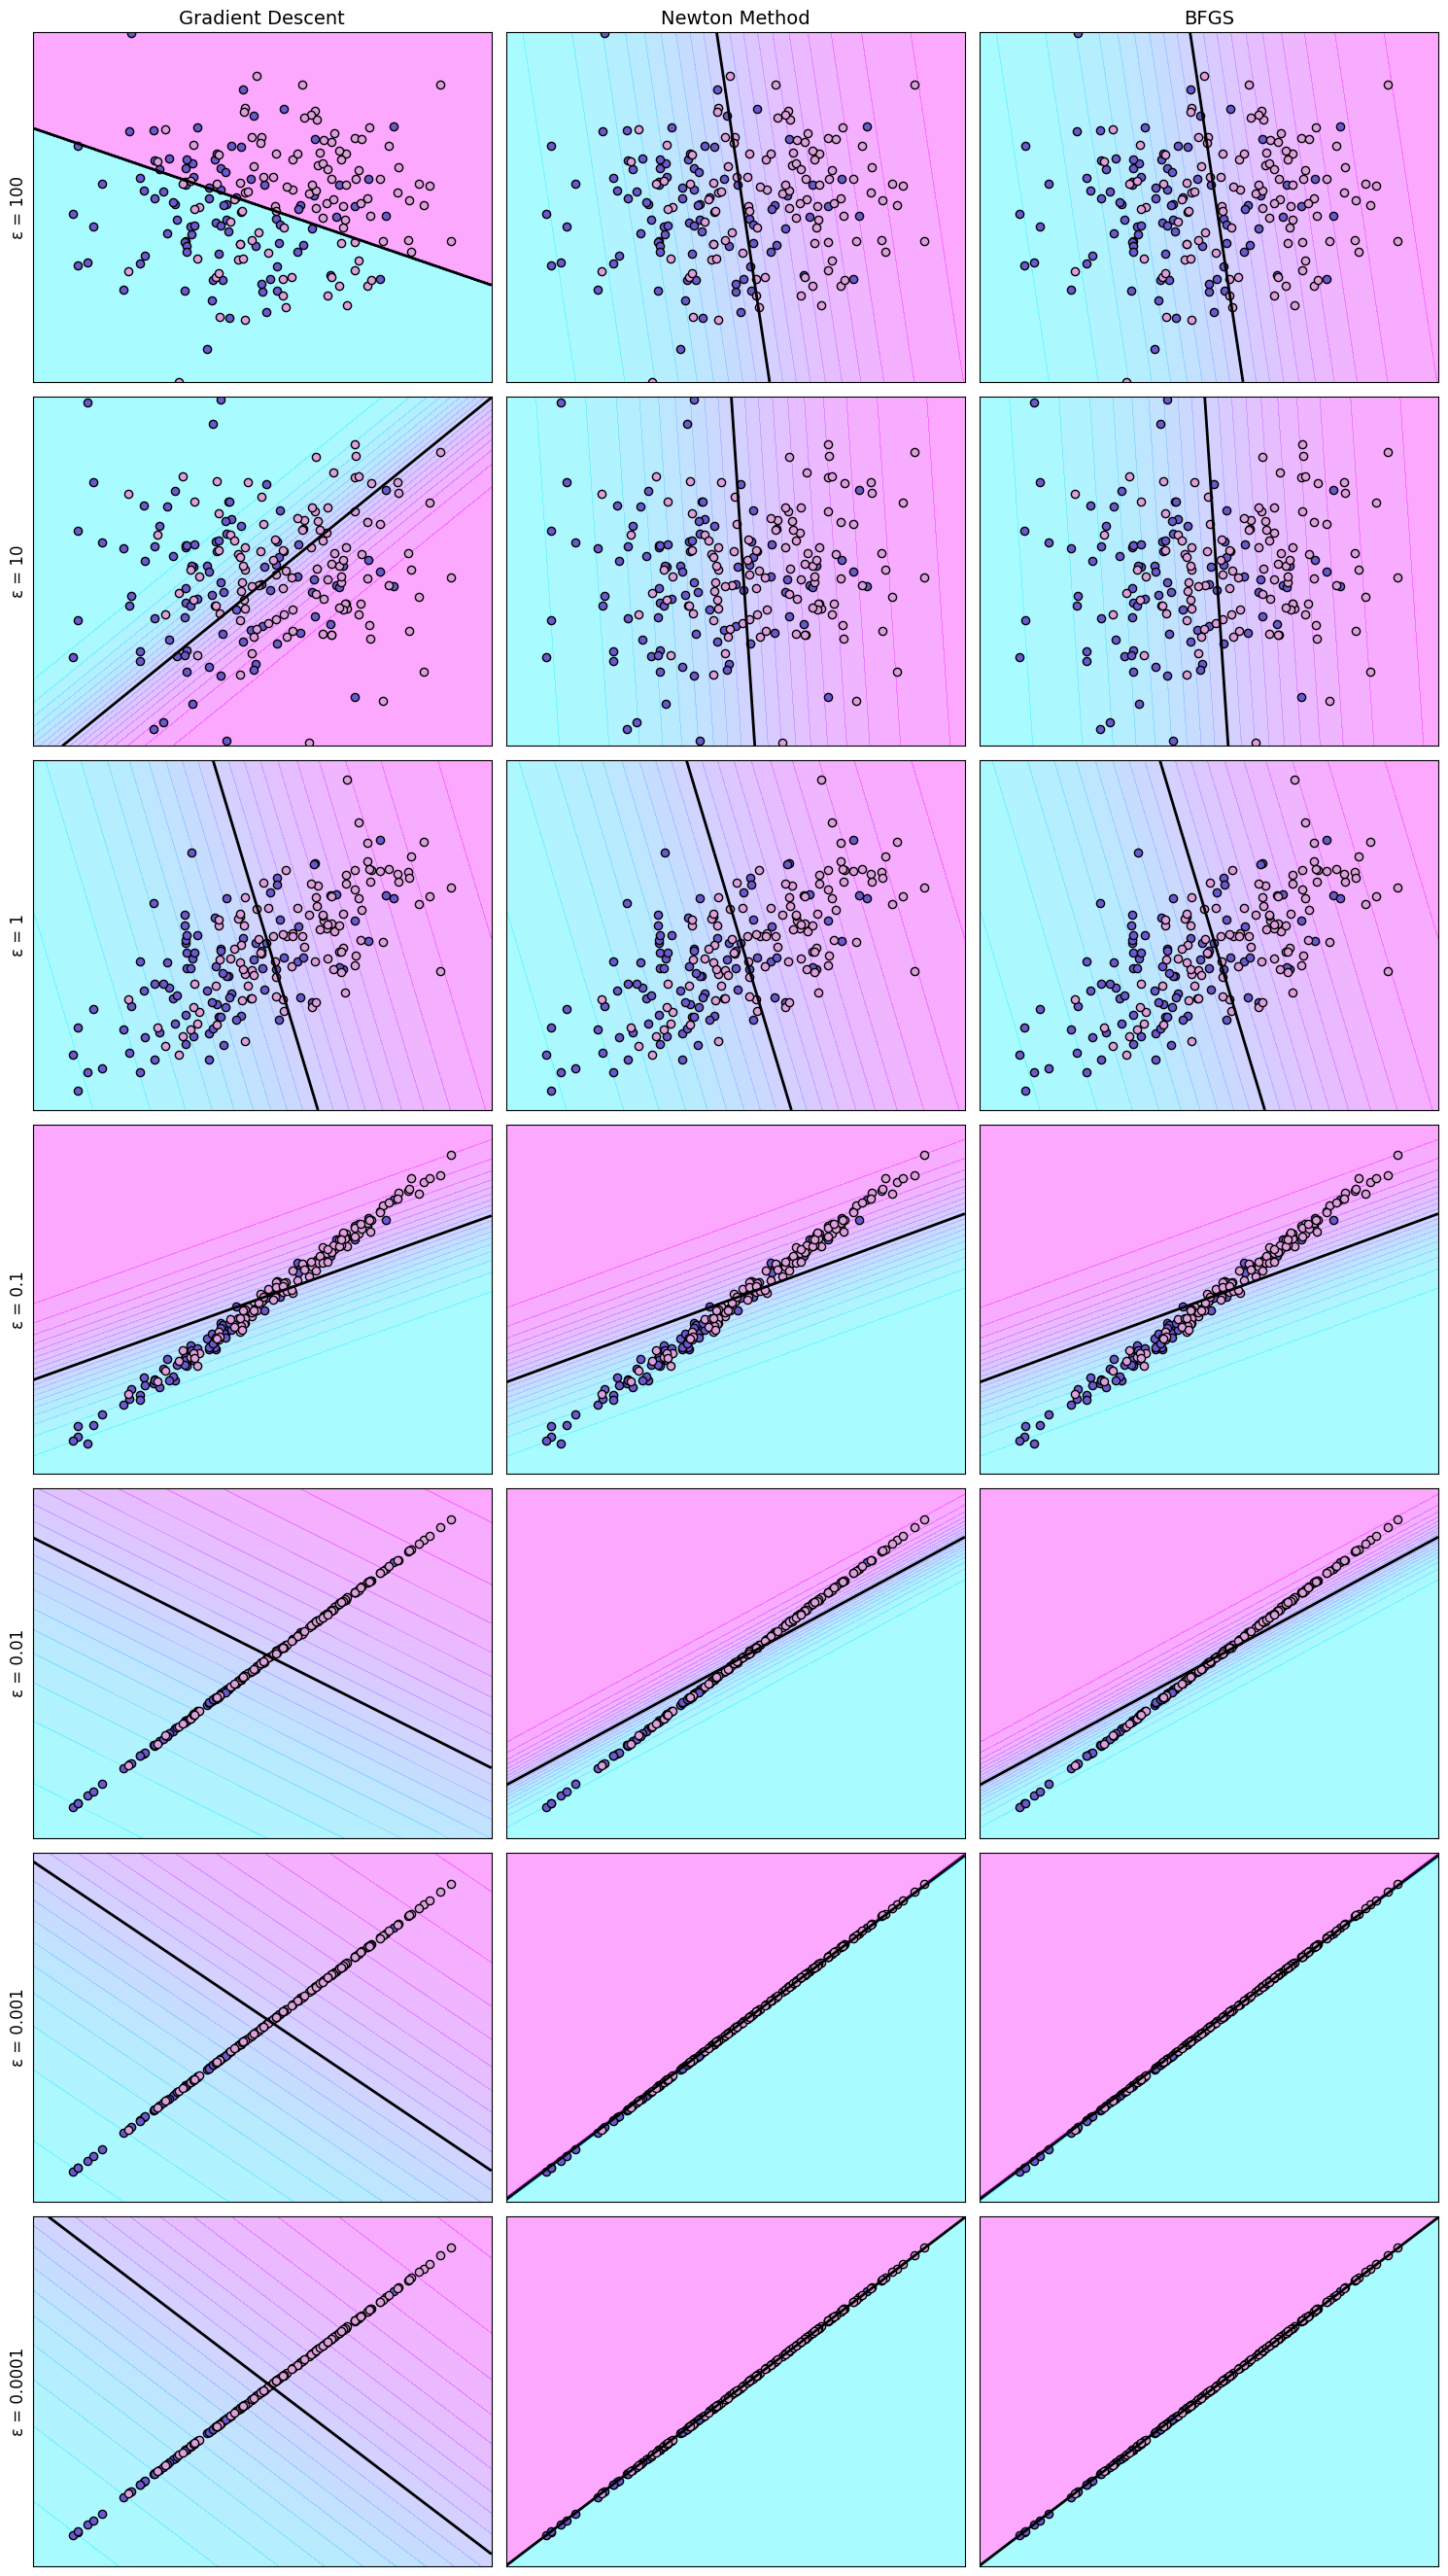

In [24]:
# Synthetic data
np.random.seed(2025)
n, p = 200, 2
X = np.random.randn(n, p)
true_w = np.array([2.0, -3.0])
logits = X @ true_w
prob = 1 / (1 + np.exp(-logits))
y = (np.random.rand(n) < prob).astype(float)

def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def softplus(t):
    out = np.empty_like(t)
    big = t > 0
    out[big] = t[big] + np.log1p(np.exp(-t[big]))
    out[~big] = np.log1p(np.exp(t[~big]))
    return out

def f(w, X, y):
    z = X @ w
    return np.mean(softplus(z) - y * z)

def grad(w, X, y):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

def hess(w, X, y):
    z = X @ w
    S = sigmoid(z) * (1.0 - sigmoid(z))
    return (X.T * S) @ X / len(y)

def gradient_descent_logistic(X, y, stepsize=0.2, epsilon=1e-6, max_iters=20000):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'w': []}
    for _ in range(max_iters):
        g = grad(w, X, y)
        w_new = w - stepsize * g
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['w'].append(w.copy())
        if np.linalg.norm(w_new - w) <= epsilon * max(1.0, np.linalg.norm(w)):
            w = w_new
            break
        w = w_new
    history['w'].append(w.copy())
    return w, history

def newton_method(X, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'step': [], 'w': [], 'direction': []}
    
    for _ in range(T):
        g = grad(w, X, y)
        H = hess(w, X, y)
        if reg > 0:
            H = H + reg * np.eye(X.shape[1])
        try:
            s = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            H = H + 1e-6 * np.eye(X.shape[1])
            s = np.linalg.solve(H, -g)

        t = 1.0
        f_curr = f(w, X, y)

        while True:
            w_try = w + t * s
            if f(w_try, X, y) <= f_curr + alpha * t * g.dot(s):
                break
            t *= beta
            if t < 1e-12:
                break

        w = w + t * s
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['step'].append(t)
        history['w'].append(w.copy())
        history['direction'].append(s.copy())

        if np.linalg.norm(g) < tol:
            break

    return w, history

def fit_bfgs(X, y, w0=None, maxiter=200):
    if w0 is None:
        w0 = np.zeros(X.shape[1])

    history = {"obj": [], "norm_g": [], "w": []}

    def obj_wrap(w):
        return f(w, X, y)

    def grad_wrap(w):
        return grad(w, X, y)

    def callback(wk):
        history["w"].append(wk.copy())
        history["obj"].append(f(wk, X, y))
        history["norm_g"].append(np.linalg.norm(grad(wk, X, y)))

    res = minimize(
        obj_wrap,
        w0,
        jac=grad_wrap,
        method="BFGS",
        callback=callback,
        options={"gtol": 1e-10, "maxiter": maxiter},
    )

    if not history["w"] or not np.allclose(history["w"][-1], res.x):
        history["w"].append(res.x.copy())
        history["obj"].append(f(res.x, X, y))
        history["norm_g"].append(np.linalg.norm(grad(res.x, X, y)))

    return res.x, history

# Fit with Gradient Descent
w_gd, hist_gd = gradient_descent_logistic(X, y, stepsize=0.2)

# Fit with Newton's Method
w_newton, hist_newton = newton_method(X, y)

# BFGS
w_bfgs, hist_bfgs = fit_bfgs(X, y, maxiter=10000)

# First 3 BFGS iterates
bfgs_directions = []
for k in range(min(3, len(hist_bfgs['w'])-1)):
    d_bfgs = hist_bfgs['w'][k+1] - hist_bfgs['w'][k]
    bfgs_directions.append(d_bfgs)
    
print("BFGS update directions (first 3):")
for i, d_bfgs in enumerate(bfgs_directions):
    print(f"d_BFGS[{i}] =", d_bfgs)
    
w0_newton = np.zeros(X.shape[1])
w_newton_list = [w0_newton] + hist_newton['w']
newton_directions = []
for k in range(min(3, len(w_newton_list)-1)):
    d_newton = w_newton_list[k+1] - w_newton_list[k]
    newton_directions.append(d_newton)
    
print("\nNewton update directions (first 3):")
for i, d_newton in enumerate(newton_directions):
    print(f"d_newton[{i}] =", d_newton)

def compute_slope(w):
    return -w[0] / w[1]

def compute_intercept(w):
    return 0.0

slope_true = compute_slope(true_w)
slope_gd = compute_slope(w_gd)
slope_newton = compute_slope(w_newton)
slope_bfgs = compute_slope(w_bfgs)

def decision_angle(w, wtrue):
    m1 = compute_slope(w)
    m2 = compute_slope(wtrue)
    numerator = abs(m1 - m2)
    denominator = abs(1 + (m1 * m2))
    theta_rad = np.arctan(numerator / denominator)
    return np.degrees(theta_rad)

angle_gd = decision_angle(w_gd, true_w)
angle_newton = decision_angle(w_newton, true_w)
angle_bfgs = decision_angle(w_bfgs, true_w)

# Make X nearly collinear: x2 ≈ x1
eps_list = [100, 10, 1, 0.1, 0.01, 0.001, 0.0001]

results = {
    "gd": {"w": {}},
    "newton": {"w": {}},
    "bfgs": {"w": {}},
}

for eps in eps_list:
    X_col = X.copy()
    X_col[:, 1] = X_col[:, 0] + eps * np.random.randn(X.shape[0])
    
    w_gd_col, _ = gradient_descent_logistic(X_col, y, stepsize=0.2, epsilon=1e-6, max_iters=20000)
    results["gd"]["w"][eps] = w_gd_col
    
    w_newton_col, _ = newton_method(X_col, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0)
    results["newton"]["w"][eps] = w_newton_col
    
    w_bfgs_col, _ = fit_bfgs(X_col, y)
    results["bfgs"]["w"][eps] = w_bfgs_col
    
    print(f"\n=== eps = {eps} ===")

print("\nDONE ✔️")

# Plot decision boundaries with new aesthetic
class_colors = {
    0: "slateblue",
    1: "plum"
}
boundary_color = "black"
prob_cmap = "cool"

def plot_decision_boundaries_all(results, X, y, eps_list):
    methods = ['gd', 'newton', 'bfgs']
    titles = {"gd": "Gradient Descent", "newton": "Newton Method", "bfgs": "BFGS"}

    fig, axes = plt.subplots(len(eps_list), len(methods),
                             figsize=(5 * len(methods), 4 * len(eps_list)))
    axes = np.atleast_2d(axes)

    for row, eps in enumerate(eps_list):
        X_col = X.copy()
        X_col[:, 1] = X_col[:, 0] + eps * np.random.randn(X.shape[0])

        x_min, x_max = X_col[:, 0].min() - 0.5, X_col[:, 0].max() + 0.5
        y_min, y_max = X_col[:, 1].min() - 0.5, X_col[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        grid = np.c_[xx.ravel(), yy.ravel()]

        for col, method in enumerate(methods):
            ax = axes[row, col]
            w = results[method]['w'][eps]

            probs = sigmoid(grid @ w).reshape(xx.shape)

            ax.contourf(xx, yy, probs, levels=20, alpha=0.35, cmap=prob_cmap)
            ax.contour(xx, yy, probs, levels=[0.5],
                       colors=boundary_color, linewidths=2)

            for cls in [0, 1]:
                idx = (y == cls)
                ax.scatter(X_col[idx, 0], X_col[idx, 1],
                           c=class_colors[cls],
                           edgecolor="k", s=35)

            if row == 0:
                ax.set_title(titles[method], fontsize=14)
            if col == 0:
                ax.set_ylabel(f"ε = {eps}", fontsize=12)

            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

plot_decision_boundaries_all(results, X, y, eps_list)

In [27]:
def plot_decision_boundaries_separate(results, X, y, eps_list):
    methods = ['gd', 'newton', 'bfgs']
    titles = {"gd": "Gradient Descent", "newton": "Newton Method", "bfgs": "BFGS"}
    class_colors = {0: "slateblue", 1: "plum"}
    boundary_color = "black"
    prob_cmap = "cool"

    for row, eps in enumerate(eps_list):
        X_col = X.copy()
        X_col[:, 1] = X_col[:, 0] + eps * np.random.randn(X.shape[0])

        x_min, x_max = X_col[:, 0].min() - 0.5, X_col[:, 0].max() + 0.5
        y_min, y_max = X_col[:, 1].min() - 0.5, X_col[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        grid = np.c_[xx.ravel(), yy.ravel()]

        fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4))

        for col, method in enumerate(methods):
            ax = axes[col]
            w = results[method]['w'][eps]

            probs = sigmoid(grid @ w).reshape(xx.shape)
            ax.contourf(xx, yy, probs, levels=20, alpha=0.35, cmap=prob_cmap)
            ax.contour(xx, yy, probs, levels=[0.5], colors=boundary_color, linewidths=2)

            for cls in [0, 1]:
                idx = (y == cls)
                ax.scatter(X_col[idx, 0], X_col[idx, 1],
                           c=class_colors[cls], edgecolor="k", s=35)

            ax.set_title(titles[method], fontsize=14)
            ax.set_xticks([])
            ax.set_yticks([])

        fig.suptitle(f"Decision Boundaries for ε = {eps}", fontsize=16)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])

        # Save the figure to Downloads folder
        filename = f"decision_boundary_eps{eps}.png"
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", filename)
        plt.savefig(downloads_path, dpi=300)
        plt.close(fig)  # free memory
        print(f"Saved: {downloads_path}")

plot_decision_boundaries_separate(results, X, y, eps_list)

Saved: /Users/sk/Downloads/decision_boundary_eps100.png
Saved: /Users/sk/Downloads/decision_boundary_eps10.png
Saved: /Users/sk/Downloads/decision_boundary_eps1.png
Saved: /Users/sk/Downloads/decision_boundary_eps0.1.png
Saved: /Users/sk/Downloads/decision_boundary_eps0.01.png
Saved: /Users/sk/Downloads/decision_boundary_eps0.001.png
Saved: /Users/sk/Downloads/decision_boundary_eps0.0001.png


In [28]:
def slope(w):
    return -w[0]/w[1]

for eps in eps_list:
    res = results_collinear[eps]
    print(f"\nε = {eps}")
    print("GD slope:", slope(res["w_gd"]))
    print("Newton slope:", slope(res["w_newton"]))
    print("BFGS slope:", slope(res["w_bfgs"]))
    print("True slope:", 2/3)



ε = 100
GD slope: -52.99806924313519
Newton slope: -2886.29912702914
BFGS slope: -2886.299768098554
True slope: 0.6666666666666666

ε = 10
GD slope: 10.235447656742583
Newton slope: -149.0757400151656
BFGS slope: -149.07614388493798
True slope: 0.6666666666666666

ε = 1
GD slope: -2.6591706435582934
Newton slope: -2.659653354996481
BFGS slope: -2.6596641128027083
True slope: 0.6666666666666666

ε = 0.1
GD slope: 0.15097365247780123
Newton slope: 0.1566288333158992
BFGS slope: 0.15663331491993826
True slope: 0.6666666666666666

ε = 0.01
GD slope: 0.11141011542608636
Newton slope: 0.9533639936716528
BFGS slope: 0.9533639781836087
True slope: 0.6666666666666666

ε = 0.001
GD slope: -1.0003729433277693
Newton slope: 1.0496003908928884
BFGS slope: -1.0000735319919258
True slope: 0.6666666666666666

ε = 0.0001
GD slope: -1.0002617211775258
Newton slope: 1.0006057297192215
BFGS slope: -1.000051237217338
True slope: 0.6666666666666666


In [31]:
def plot_decision_boundaries_regularized(results, X, y, eps_list, lambda_list):
    methods = ['gd', 'newton', 'bfgs']
    titles = {"gd": "Gradient Descent", "newton": "Newton Method", "bfgs": "BFGS"}
    class_colors = {0: "slateblue", 1: "plum"}
    boundary_color = "black"
    prob_cmap = "cool"

    for eps in eps_list:
        X_col = X.copy()
        X_col[:, 1] = X_col[:, 0] + eps * np.random.randn(X.shape[0])

        x_min, x_max = X_col[:, 0].min() - 0.5, X_col[:, 0].max() + 0.5
        y_min, y_max = X_col[:, 1].min() - 0.5, X_col[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        grid = np.c_[xx.ravel(), yy.ravel()]

        for reg_lambda in lambda_list:
            fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4))

            for col, method in enumerate(methods):
                ax = axes[col]
                w = results[method]['w'][(eps, reg_lambda)]  # now results keyed by (eps, lambda)

                probs = sigmoid(grid @ w).reshape(xx.shape)
                ax.contourf(xx, yy, probs, levels=20, alpha=0.35, cmap=prob_cmap)
                ax.contour(xx, yy, probs, levels=[0.5], colors=boundary_color, linewidths=2)

                for cls in [0, 1]:
                    idx = (y == cls)
                    ax.scatter(X_col[idx, 0], X_col[idx, 1],
                               c=class_colors[cls], edgecolor="k", s=35)

                ax.set_title(titles[method], fontsize=14)
                ax.set_xticks([])
                ax.set_yticks([])

            fig.suptitle(f"Decision Boundaries ε = {eps}, λ = {reg_lambda}", fontsize=16)
            plt.tight_layout(rect=[0, 0.05, 1, 0.95])

            # Save figure
            filename = f"decision_boundary_eps{eps}_lambda{reg_lambda}.png"
            downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", filename)
            plt.savefig(downloads_path, dpi=300)
            plt.close(fig)
            print(f"Saved: {downloads_path}")

In [34]:
def slope(w):
    return -w[0]/w[1]

for eps in eps_list:
    res = results_collinear[eps]
    print(f"\nε = {eps}")
    print("GD slope:", slope(res["w_gd"]))
    print("Newton slope:", slope(res["w_newton"]))
    print("BFGS slope:", slope(res["w_bfgs"]))
    print("True slope:", 2/3)


ε = 100
GD slope: -52.99806924313519
Newton slope: -2886.29912702914
BFGS slope: -2886.299768098554
True slope: 0.6666666666666666

ε = 10
GD slope: 10.235447656742583
Newton slope: -149.0757400151656
BFGS slope: -149.07614388493798
True slope: 0.6666666666666666

ε = 1
GD slope: -2.6591706435582934
Newton slope: -2.659653354996481
BFGS slope: -2.6596641128027083
True slope: 0.6666666666666666

ε = 0.1
GD slope: 0.15097365247780123
Newton slope: 0.1566288333158992
BFGS slope: 0.15663331491993826
True slope: 0.6666666666666666

ε = 0.01
GD slope: 0.11141011542608636
Newton slope: 0.9533639936716528
BFGS slope: 0.9533639781836087
True slope: 0.6666666666666666

ε = 0.001
GD slope: -1.0003729433277693
Newton slope: 1.0496003908928884
BFGS slope: -1.0000735319919258
True slope: 0.6666666666666666

ε = 0.0001
GD slope: -1.0002617211775258
Newton slope: 1.0006057297192215
BFGS slope: -1.000051237217338
True slope: 0.6666666666666666


In [35]:
# ===============================================================
# Compute angles between non-regularised Newton decision boundaries
# and the true boundary for collinear data
# ===============================================================

def compute_slope(w):
    return -w[0] / w[1]

def compute_angle(w, wtrue):
    m1 = compute_slope(w)
    m2 = compute_slope(wtrue)
    numerator   = abs(m1 - m2)
    denominator = abs(1 + m1 * m2)
    theta_rad   = np.arctan(numerator / denominator)
    return np.degrees(theta_rad)

angles_newton_col = {}

for eps in eps_list:
    w_newton_col = results_collinear[eps]["w_newton"]
    angle = compute_angle(w_newton_col, true_w)
    angles_newton_col[eps] = angle

# Print results
print("Angles between non-regularised Newton boundaries and true boundary (degrees):")
for eps, angle in angles_newton_col.items():
    print(f"eps = {eps}: angle = {angle:.4f}°")

Angles between non-regularised Newton boundaries and true boundary (degrees):
eps = 100: angle = 56.3298°
eps = 10: angle = 56.6943°
eps = 1: angle = 76.9156°
eps = 0.1: angle = 24.7882°
eps = 0.01: angle = 9.9423°
eps = 0.001: angle = 12.6962°
eps = 0.0001: angle = 11.3273°


In [36]:
# --- Regularized Newton's Method for collinear data ---
def newton_method_reg(X, y, reg=1e-2, T=50, tol=1e-10, alpha=0.25, beta=0.5):
    """Newton method with Hessian regularization"""
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'step': [], 'w': [], 'direction': []}
    for _ in range(T):
        g = grad(w, X, y)
        H = hess(w, X, y)
        # Add regularization term
        H_reg = H + reg * np.eye(X.shape[1])
        try:
            s = np.linalg.solve(H_reg, -g)
        except np.linalg.LinAlgError:
            H_reg = H_reg + 1e-6 * np.eye(X.shape[1])
            s = np.linalg.solve(H_reg, -g)
        t = 1.0
        f_curr = f(w, X, y)
        # Backtracking line search
        while True:
            w_try = w + t * s
            if f(w_try, X, y) <= f_curr + alpha * t * g.dot(s):
                break
            t *= beta
            if t < 1e-12:
                break
        w = w + t * s
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['step'].append(t)
        history['w'].append(w.copy())
        history['direction'].append(s.copy())
        if np.linalg.norm(g) < tol:
            break
    return w, history

# Choose one nearly collinear dataset (eps = 1e-4 as an example)
X_col = results_collinear[1e-4]["X_col"]
y_col = y

# Run Newton with and without regularization
w_newton_no_reg, hist_no_reg = newton_method(X_col, y_col, T=50, reg=0.0)
w_newton_reg, hist_reg = newton_method_reg(X_col, y_col, reg=1e-2, T=50)

# Compute Hessian eigenvalues at the final iterate
H_no_reg = hess(w_newton_no_reg, X_col, y_col)
H_reg = hess(w_newton_reg, X_col, y_col) + 1e-2 * np.eye(X_col.shape[1])

eigvals_no_reg = np.linalg.eigvalsh(H_no_reg)
eigvals_reg = np.linalg.eigvalsh(H_reg)

print("\n=== Hessian eigenvalues at final iterate ===")
print("Without regularization:", eigvals_no_reg)
print("Smallest eigenvalue (no reg):", eigvals_no_reg.min())
print("With regularization:", eigvals_reg)
print("Smallest eigenvalue (with reg):", eigvals_reg.min())


=== Hessian eigenvalues at final iterate ===
Without regularization: [9.60027533e-10 2.47917749e-01]
Smallest eigenvalue (no reg): 9.600275334434669e-10
With regularization: [0.01       0.26338479]
Smallest eigenvalue (with reg): 0.010000000987621745


In [38]:
# List of eps values and lambda values
eps_list = [100, 10, 1, 1e-1, 1e-2, 1e-3, 1e-4]
lambda_list = [1e-4, 1e-2, 1]  # multiple regularization strengths

print("=== Smallest Hessian eigenvalues for all eps and lambda ===\n")

for eps in eps_list:
    X_col = results_collinear[eps]["X_col"]
    
    # Newton without regularization
    w_no_reg, _ = newton_method(X_col, y, T=50, reg=0.0)
    H_no_reg = hess(w_no_reg, X_col, y)
    eig_no_reg = np.linalg.eigvalsh(H_no_reg)
    
    print(f"eps = {eps}")
    print(f"  Smallest eigenvalue (no reg): {eig_no_reg.min():.6e}")
    
    # Loop over different lambda values
    for reg_lambda in lambda_list:
        w_reg, _ = newton_method_reg(X_col, y, reg=reg_lambda, T=50)
        H_reg = hess(w_reg, X_col, y) + reg_lambda * np.eye(X_col.shape[1])
        eig_reg = np.linalg.eigvalsh(H_reg)
        print(f"  Smallest eigenvalue (reg λ={reg_lambda}): {eig_reg.min():.6e}")
    print()

=== Smallest Hessian eigenvalues for all eps and lambda ===

eps = 100
  Smallest eigenvalue (no reg): 1.265633e-01
  Smallest eigenvalue (reg λ=0.0001): 1.266633e-01
  Smallest eigenvalue (reg λ=0.01): 1.365633e-01
  Smallest eigenvalue (reg λ=1): 1.126789e+00

eps = 10
  Smallest eigenvalue (no reg): 1.265269e-01
  Smallest eigenvalue (reg λ=0.0001): 1.266269e-01
  Smallest eigenvalue (reg λ=0.01): 1.365269e-01
  Smallest eigenvalue (reg λ=1): 1.126753e+00

eps = 1
  Smallest eigenvalue (no reg): 6.469375e-02
  Smallest eigenvalue (reg λ=0.0001): 6.479375e-02
  Smallest eigenvalue (reg λ=0.01): 7.469375e-02
  Smallest eigenvalue (reg λ=1): 1.065096e+00

eps = 0.1
  Smallest eigenvalue (no reg): 1.115130e-03
  Smallest eigenvalue (reg λ=0.0001): 1.215130e-03
  Smallest eigenvalue (reg λ=0.01): 1.111518e-02
  Smallest eigenvalue (reg λ=1): 1.001121e+00

eps = 0.01
  Smallest eigenvalue (no reg): 7.331706e-06
  Smallest eigenvalue (reg λ=0.0001): 1.073446e-04
  Smallest eigenvalue (reg 

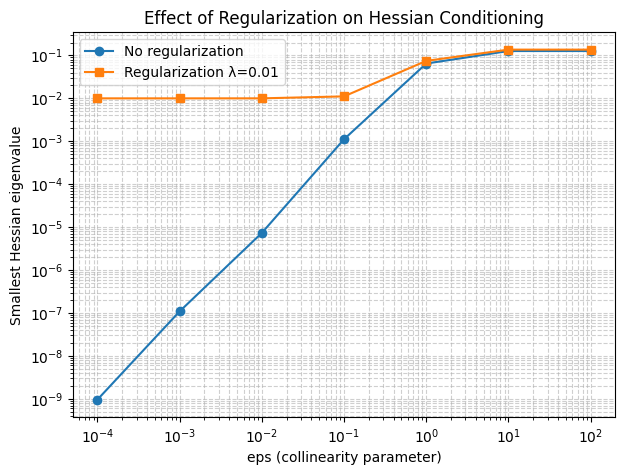

In [39]:
eps_list = [100, 10, 1, 1e-1, 1e-2, 1e-3, 1e-4]
reg_lambda = 1e-2

eig_min_no_reg = []
eig_min_reg = []

for eps in eps_list:
    X_col = results_collinear[eps]["X_col"]
    
    # Newton without regularization
    w_no_reg, _ = newton_method(X_col, y, T=50, reg=0.0)
    H_no_reg = hess(w_no_reg, X_col, y)
    eig_min_no_reg.append(np.linalg.eigvalsh(H_no_reg).min())
    
    # Newton with regularization
    w_reg, _ = newton_method_reg(X_col, y, reg=reg_lambda, T=50)
    H_reg = hess(w_reg, X_col, y) + reg_lambda * np.eye(X_col.shape[1])
    eig_min_reg.append(np.linalg.eigvalsh(H_reg).min())

# Plot
plt.figure(figsize=(7,5))
plt.plot(eps_list, eig_min_no_reg, 'o-', label='No regularization')
plt.plot(eps_list, eig_min_reg, 's-', label=f'Regularization λ={reg_lambda}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('eps (collinearity parameter)')
plt.ylabel('Smallest Hessian eigenvalue')
plt.title('Effect of Regularization on Hessian Conditioning')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.show()

In [40]:
# List of eps values and regularization strengths
eps_list = [1e-1, 1e-2, 1e-3, 1e-4]
lambda_list = [0.0, 1e-4, 1e-2, 1]  # include no regularization

print("=== Hessian Condition Numbers for all eps and lambda ===\n")

for eps in eps_list:
    X_col = results_collinear[eps]["X_col"]
    
    print(f"eps = {eps}")
    
    for reg_lambda in lambda_list:
        if reg_lambda == 0.0:
            w, _ = newton_method(X_col, y, T=50, reg=0.0)
            H = hess(w, X_col, y)
        else:
            w, _ = newton_method_reg(X_col, y, reg=reg_lambda, T=50)
            H = hess(w, X_col, y) + reg_lambda * np.eye(X_col.shape[1])
        
        eigvals = np.linalg.eigvalsh(H)
        cond_number = eigvals.max() / eigvals.min()
        
        print(f"  λ = {reg_lambda:.4f} -> Condition number: {cond_number}")
    print()

=== Hessian Condition Numbers for all eps and lambda ===

eps = 0.1
  λ = 0.0000 -> Condition number: 228.65309637523288
  λ = 0.0001 -> Condition number: 209.91822375138355
  λ = 0.0100 -> Condition number: 23.83923438896932
  λ = 1.0000 -> Condition number: 1.2531843536330667

eps = 0.01
  λ = 0.0000 -> Condition number: 34403.10771335029
  λ = 0.0001 -> Condition number: 2351.4318107271215
  λ = 0.0100 -> Condition number: 26.292313353344664
  λ = 1.0000 -> Condition number: 1.2530708962918256

eps = 0.001
  λ = 0.0000 -> Condition number: 2323654.4237453933
  λ = 0.0001 -> Condition number: 2532.079307901019
  λ = 0.0100 -> Condition number: 26.33772418816249
  λ = 1.0000 -> Condition number: 1.2533822392924738

eps = 0.0001
  λ = 0.0000 -> Condition number: 258240248.27910608
  λ = 0.0001 -> Condition number: 2534.80375846948
  λ = 0.0100 -> Condition number: 26.33847658879985
  λ = 1.0000 -> Condition number: 1.2533871127507166



Saved: /Users/sk/Downloads/newton_decision_boundaries_lambda0.0001.png
Saved: /Users/sk/Downloads/newton_decision_boundaries_lambda0.01.png
Saved: /Users/sk/Downloads/newton_decision_boundaries_lambda1.png
Slopes and angles relative to true slope (degrees):

λ = 0.0001
eps=1e-01: No reg -> slope=0.1566, angle=24.79° | Reg -> slope=0.1566, angle=24.79°
eps=1e-02: No reg -> slope=0.9534, angle=9.94° | Reg -> slope=0.9521, angle=9.90°
eps=1e-03: No reg -> slope=1.0496, angle=12.70° | Reg -> slope=2.6676, angle=35.76°
eps=1e-04: No reg -> slope=1.0006, angle=11.33° | Reg -> slope=4.1022, angle=42.61°

λ = 0.01
eps=1e-01: No reg -> slope=0.1566, angle=24.79° | Reg -> slope=0.1542, angle=24.93°
eps=1e-02: No reg -> slope=0.9534, angle=9.94° | Reg -> slope=0.2184, angle=21.37°
eps=1e-03: No reg -> slope=1.0496, angle=12.70° | Reg -> slope=-1.0463, angle=79.99°
eps=1e-04: No reg -> slope=1.0006, angle=11.33° | Reg -> slope=-1.0334, angle=79.63°

λ = 1
eps=1e-01: No reg -> slope=0.1566, angle=2

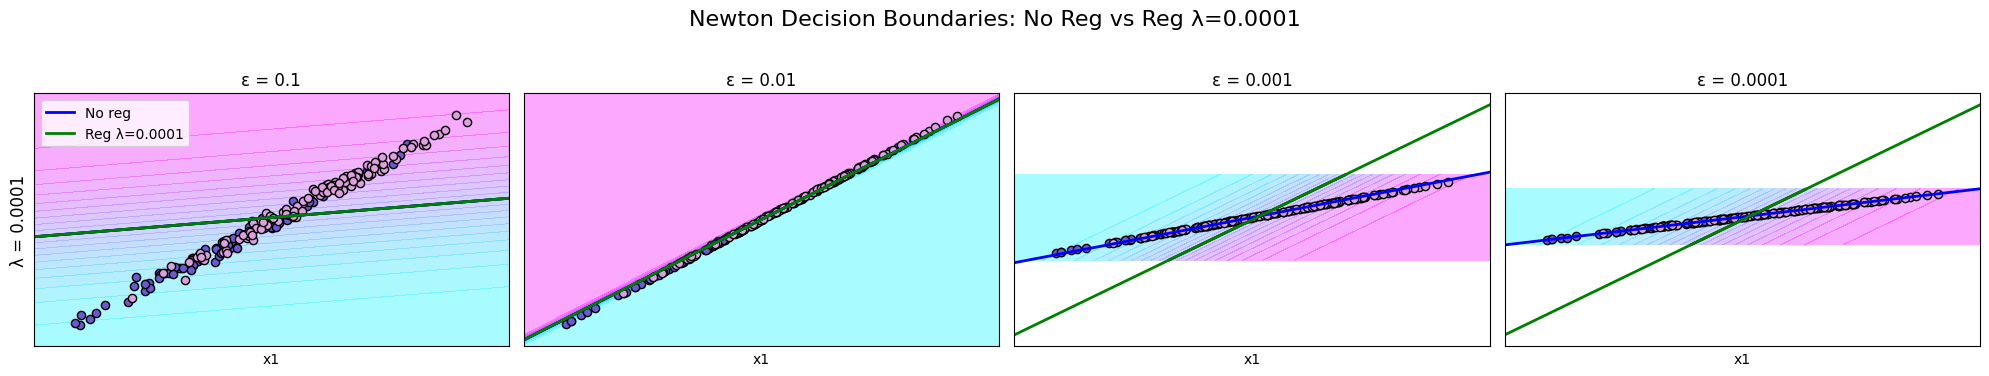

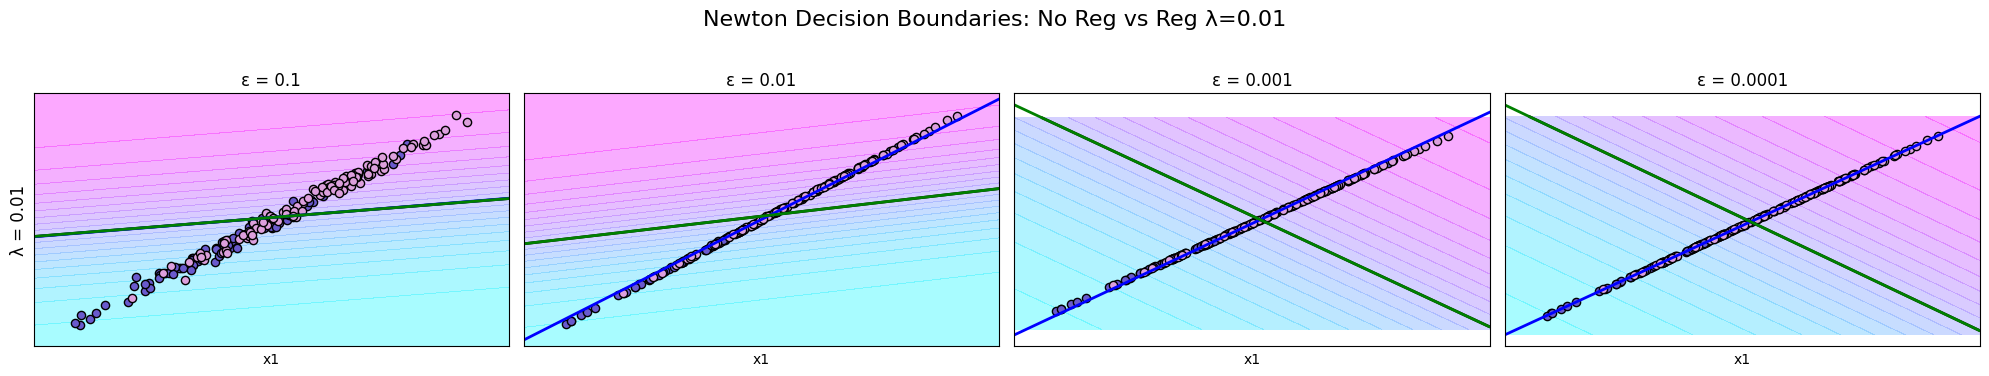

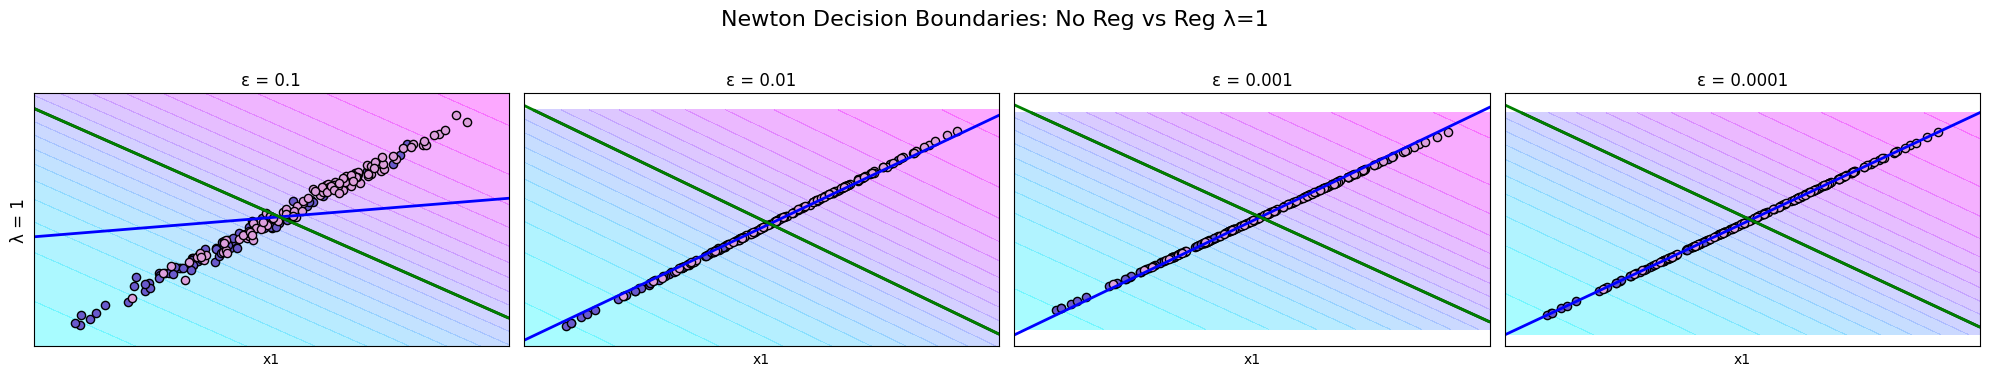

In [44]:
# Colors and plotting style
class_colors = {0: "slateblue", 1: "plum"}
boundary_color = "black"
prob_cmap = "cool"

# Lambda values for regularization
lambda_list = [1e-4, 1e-2, 1]

# Store results
results_angles = {}

# Loop over lambda values (rows)
for r, reg_lambda in enumerate(lambda_list):
    results_angles[reg_lambda] = {}

    fig, axes = plt.subplots(1, len(eps_list), figsize=(5*len(eps_list), 4))
    fig.suptitle(f"Newton Decision Boundaries: No Reg vs Reg λ={reg_lambda}", fontsize=16)

    for c, eps in enumerate(eps_list):
        X_col = results_collinear[eps]["X_col"]

        # Newton without reg
        w_no_reg, _ = newton_method(X_col, y, T=50, reg=0.0)
        # Newton with reg
        w_reg, _ = newton_method(X_col, y, T=50, reg=reg_lambda)

        # Compute slopes & angles
        slope_no_reg = -w_no_reg[0]/w_no_reg[1]
        slope_reg = -w_reg[0]/w_reg[1]
        angle_no_reg = angle_between_slopes(slope_no_reg, true_slope)
        angle_reg = angle_between_slopes(slope_reg, true_slope)

        # Store
        results_angles[reg_lambda][eps] = {
            "slope_no_reg": slope_no_reg,
            "slope_reg": slope_reg,
            "angle_no_reg": angle_no_reg,
            "angle_reg": angle_reg
        }

        # Meshgrid for probability contour
        x_min, x_max = X_col[:,0].min() - 0.5, X_col[:,0].max() + 0.5
        y_min, y_max = X_col[:,1].min() - 0.5, X_col[:,1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        grid = np.c_[xx.ravel(), yy.ravel()]

        ax = axes[c]

        # Plot probabilities
        probs_no_reg = sigmoid(grid @ w_no_reg).reshape(xx.shape)
        probs_reg = sigmoid(grid @ w_reg).reshape(xx.shape)

        ax.contourf(xx, yy, probs_reg, levels=20, alpha=0.35, cmap=prob_cmap)
        ax.contour(xx, yy, probs_reg, levels=[0.5], colors=boundary_color, linewidths=2)

        # Scatter points
        for cls in [0,1]:
            idx = (y == cls)
            ax.scatter(X_col[idx,0], X_col[idx,1], c=class_colors[cls],
                       edgecolor="k", s=35)

        # Decision lines
        x_range = np.linspace(x_min, x_max, 300)
        ax.plot(x_range, -w_no_reg[0]/w_no_reg[1]*x_range, 'b', linewidth=2, label='No reg')
        ax.plot(x_range, -w_reg[0]/w_reg[1]*x_range, 'g', linewidth=2, label=f'Reg λ={reg_lambda}')

        ax.set_title(f"ε = {eps}", fontsize=12)
        ax.set_xlabel("x1")
        if c == 0:
            ax.set_ylabel(f"λ = {reg_lambda}", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 0 and c == 0:
            ax.legend()

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    # Save each row (lambda) separately
    filename = f"newton_decision_boundaries_lambda{reg_lambda}.png"
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", filename)
    plt.savefig(downloads_path, dpi=300)
    print(f"Saved: {downloads_path}")

# Print slopes and angles
print("Slopes and angles relative to true slope (degrees):")
for reg_lambda in lambda_list:
    print(f"\nλ = {reg_lambda}")
    for eps in eps_list:
        data = results_angles[reg_lambda][eps]
        print(f"eps={eps:.0e}: No reg -> slope={data['slope_no_reg']:.4f}, angle={data['angle_no_reg']:.2f}° | "
              f"Reg -> slope={data['slope_reg']:.4f}, angle={data['angle_reg']:.2f}°")


================ REGULARISED NEWTON EXPERIMENTS ================


===== Collinearity eps = 0.1 =====
  λ = 0.0001
    iterations: 9
  λ = 0.5
    iterations: 50

===== Collinearity eps = 0.01 =====
  λ = 0.0001
    iterations: 50
  λ = 0.5
    iterations: 50

===== Collinearity eps = 0.001 =====
  λ = 0.0001
    iterations: 50
  λ = 0.5
    iterations: 50

===== Collinearity eps = 0.0001 =====
  λ = 0.0001
    iterations: 50
  λ = 0.5
    iterations: 50
Saved: /Users/sk/Downloads/newton_reg_decision_eps0.1.png
Saved: /Users/sk/Downloads/newton_reg_decision_eps0.01.png
Saved: /Users/sk/Downloads/newton_reg_decision_eps0.001.png
Saved: /Users/sk/Downloads/newton_reg_decision_eps0.0001.png


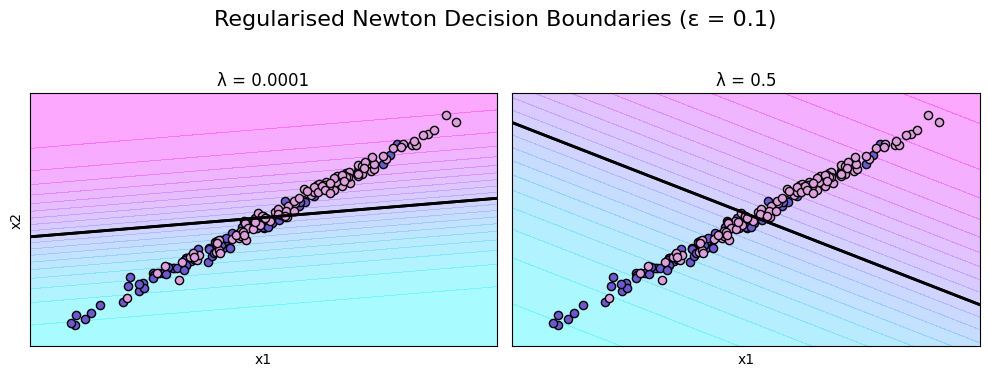

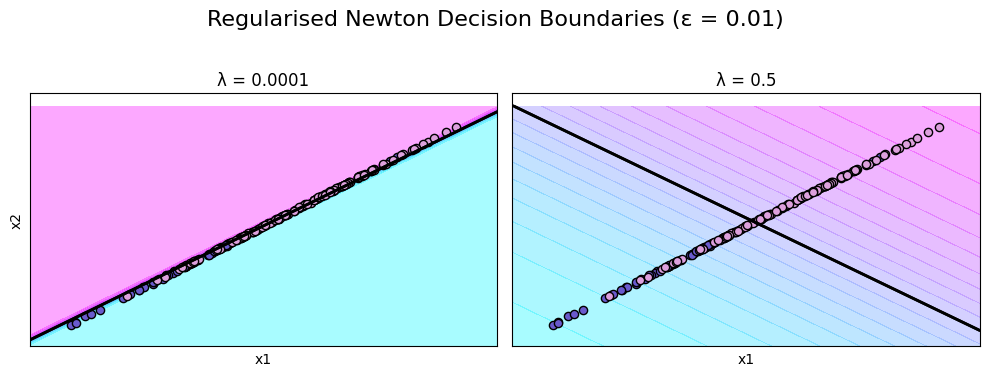

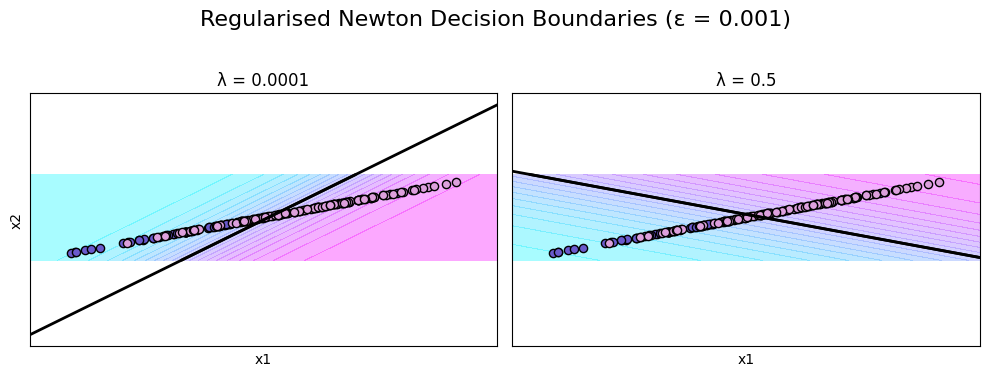

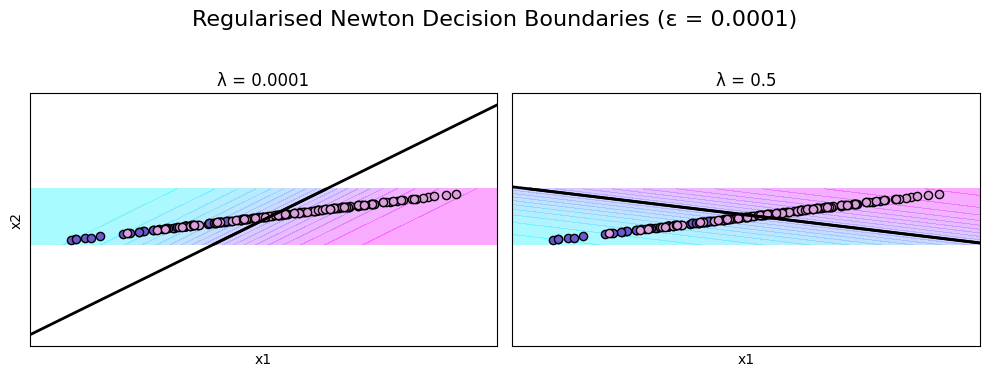

In [48]:
# Colors and plotting style
class_colors = {0: "slateblue", 1: "plum"}
boundary_color = "black"
prob_cmap = "cool"

# Lambda values
lambda_list = [1e-4, 0.5]  # adjustable
results_collinear_reg = {}

print("\n================ REGULARISED NEWTON EXPERIMENTS ================\n")

# Run experiments
for eps in eps_list:
    print(f"\n===== Collinearity eps = {eps} =====")
    X_col = np.copy(results_collinear[eps]["X_col"])
    results_collinear_reg[eps] = {}

    for lam in lambda_list:
        print(f"  λ = {lam}")
        w_newton_reg, hist_newton_reg = newton_method(
            X_col, y,
            T=50,
            tol=1e-10,
            alpha=0.25,
            beta=0.5,
            reg=lam
        )
        results_collinear_reg[eps][lam] = {
            "w_newton_reg": w_newton_reg,
            "hist_newton_reg": hist_newton_reg,
        }
        print(f"    iterations: {len(hist_newton_reg['obj'])}")

# Plot decision boundaries for each eps with all λ values
for eps in eps_list:
    X_col = np.copy(results_collinear[eps]["X_col"])
    x_min, x_max = X_col[:,0].min() - 0.5, X_col[:,0].max() + 0.5
    y_min, y_max = X_col[:,1].min() - 0.5, X_col[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    fig, axes = plt.subplots(1, len(lambda_list), figsize=(5*len(lambda_list), 4), sharey=True)
    fig.suptitle(f"Regularised Newton Decision Boundaries (ε = {eps})", fontsize=16)

    for j, lam in enumerate(lambda_list):
        w_reg = results_collinear_reg[eps][lam]["w_newton_reg"]
        ax = axes[j]

        # Probability background
        probs = sigmoid(grid @ w_reg).reshape(xx.shape)
        ax.contourf(xx, yy, probs, levels=20, alpha=0.35, cmap=prob_cmap)
        ax.contour(xx, yy, probs, levels=[0.5], colors=boundary_color, linewidths=2)

        # Scatter points
        for cls in [0,1]:
            idx = (y == cls)
            ax.scatter(X_col[idx,0], X_col[idx,1], c=class_colors[cls],
                       edgecolor="k", s=35)

        # Decision boundary
        x_range = np.linspace(x_min, x_max, 300)
        ax.plot(x_range, -(w_reg[0]/w_reg[1])*x_range, 'k', linewidth=2)

        ax.set_title(f"λ = {lam}", fontsize=12)
        ax.set_xlabel("x1")
        if j == 0:
            ax.set_ylabel("x2")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    # Save each row separately
    filename = f"newton_reg_decision_eps{eps}.png"
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", filename)
    plt.savefig(downloads_path, dpi=300)
    print(f"Saved: {downloads_path}")

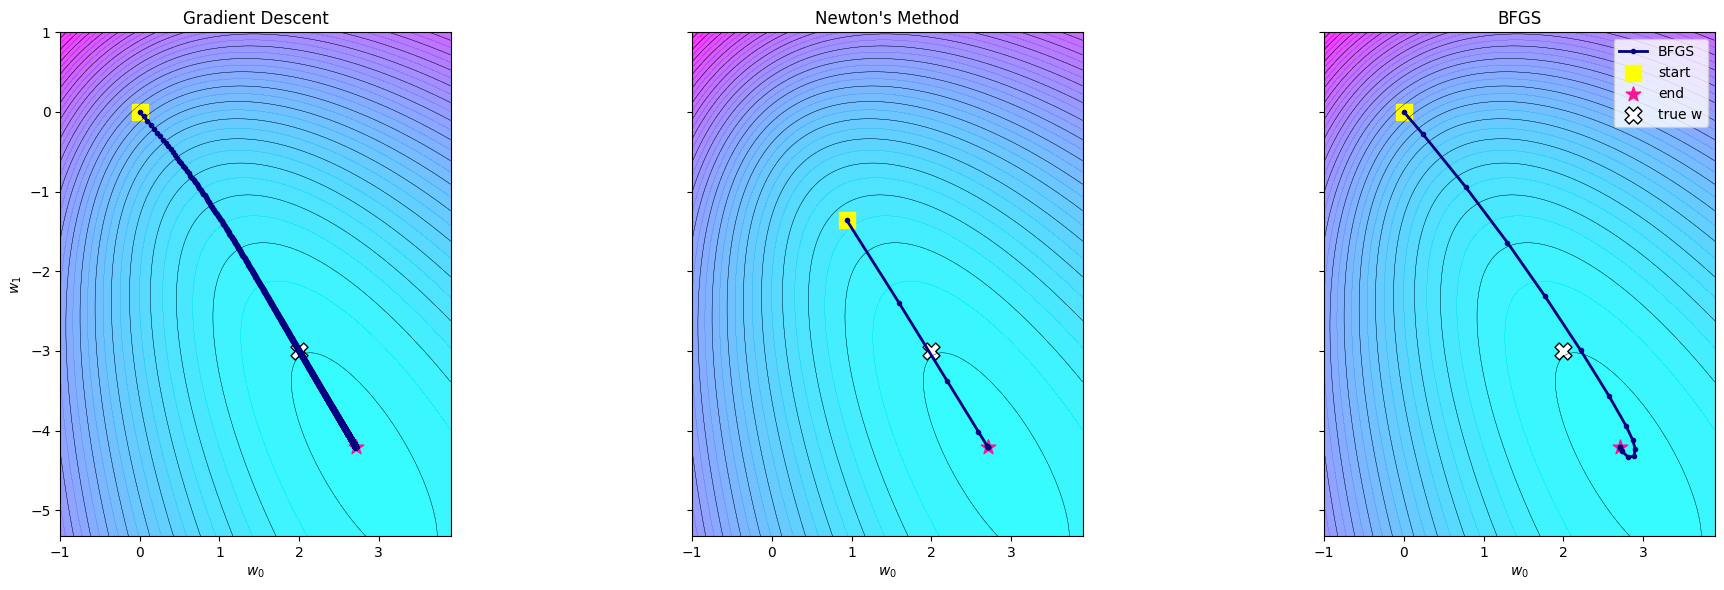

In [72]:
# =========================================================
# 6. Side-by-side subplot grid (1×3)
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

method_names = ["Gradient Descent", "Newton's Method", "BFGS"]
paths = [np.array(hist_gd['w']),
         np.array(hist_newton['w']),
         np.array(bfgs_w_history)]

for ax, name, w_list in zip(axes, method_names, paths):

    # Contours
    cs = ax.contourf(W0, W1, Z, levels=40, cmap="cool", alpha=0.8)
    ax.contour(W0, W1, Z, levels=20, colors='black', linewidths=0.3)

    # Path
    ax.plot(w_list[:,0], w_list[:,1], '-o', markersize=3, linewidth=2, label=name, color='navy')

    # Start, end, true
    ax.scatter(w_list[0,0], w_list[0,1], s=120, marker='s', label='start', color='yellow')
    ax.scatter(w_list[-1,0], w_list[-1,1], s=120, marker='*', label='end', color='deeppink')
    ax.scatter(true_w[0], true_w[1], s=150, marker='X',
               edgecolors='black', color='white', label='true w')

    ax.set_title(name)
    ax.set_xlabel("$w_0$")
    ax.set_aspect('equal', adjustable='box')

axes[0].set_ylabel("$w_1$")
axes[-1].legend(loc="upper right", fontsize=10)

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "contours.png")
plt.savefig(downloads_path, dpi=300)
plt.show()

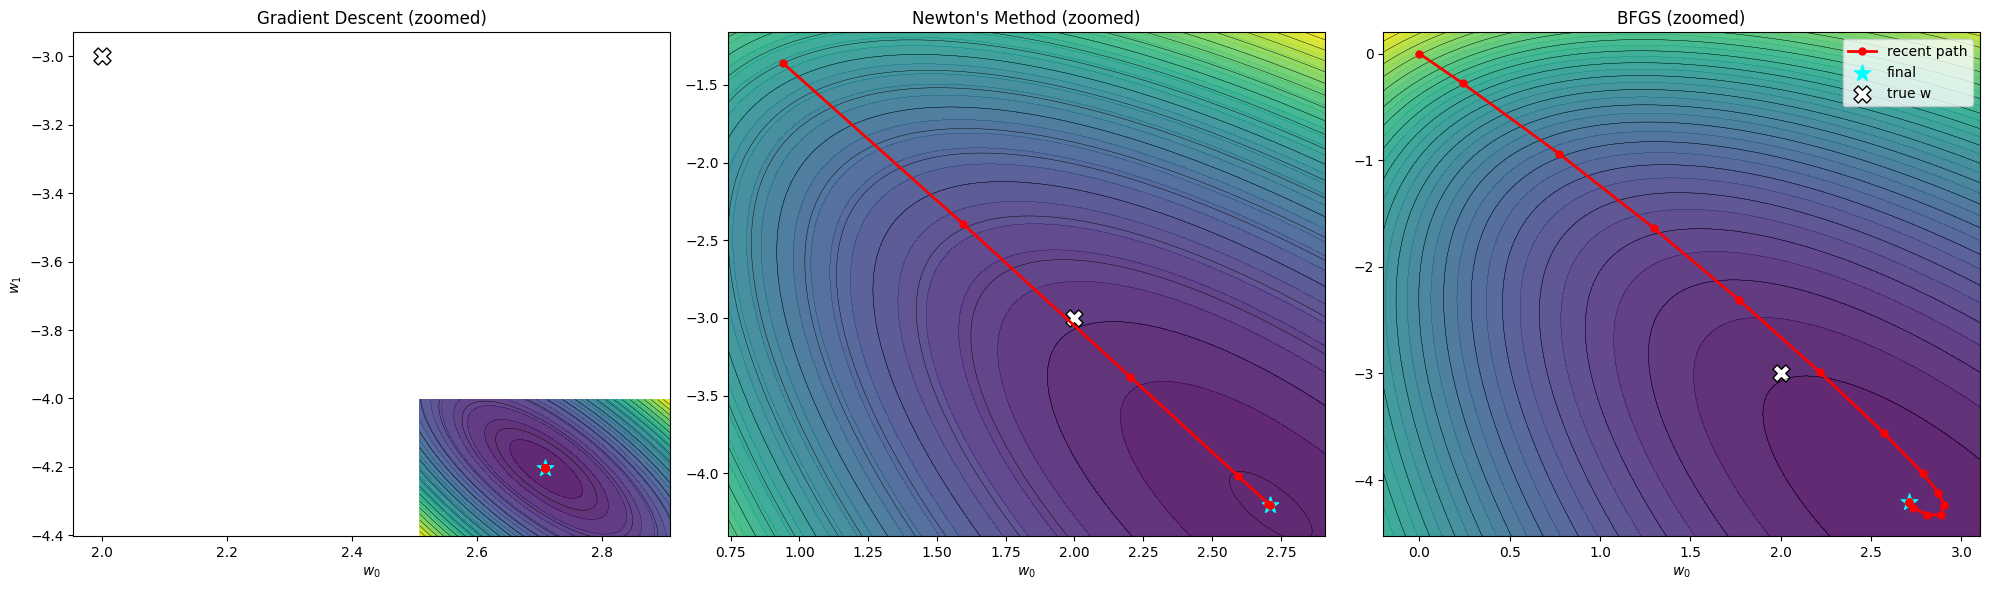

In [71]:
# Improved zoomed-in contour plots around final iterates
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

method_names = ["Gradient Descent", "Newton's Method", "BFGS"]
paths = [np.array(hist_gd['w']),
         np.array(hist_newton['w']),
         np.array(bfgs_w_history)]

for ax, name, w_list in zip(axes, method_names, paths):

    w_final = w_list[-1]

    # --- Adaptive zoom radius ---
    # Look at last 20 steps (or fewer if needed)
    k = min(20, len(w_list))
    recent_steps = w_list[-k:]

    # Compute bounding box of the last steps
    w0_min, w0_max = recent_steps[:,0].min(), recent_steps[:,0].max()
    w1_min, w1_max = recent_steps[:,1].min(), recent_steps[:,1].max()

    # Add small padding (prevents the red line from touching borders)
    pad = 0.2
    w0_min -= pad
    w0_max += pad
    w1_min -= pad
    w1_max += pad

    # New zoom grid
    W0_zoom, W1_zoom = np.meshgrid(
        np.linspace(w0_min, w0_max, 300),
        np.linspace(w1_min, w1_max, 300)
    )

    Z_zoom = np.zeros_like(W0_zoom)
    for i in range(W0_zoom.shape[0]):
        for j in range(W0_zoom.shape[1]):
            Z_zoom[i, j] = f(np.array([W0_zoom[i, j], W1_zoom[i, j]]), X, y)

    # Plot zoomed contours
    ax.contourf(W0_zoom, W1_zoom, Z_zoom, levels=40, cmap="viridis", alpha=0.85)
    ax.contour(W0_zoom, W1_zoom, Z_zoom, levels=20, colors="black", linewidths=0.3)

    # Plot full recent trajectory (at least 20 steps)
    ax.plot(recent_steps[:,0], recent_steps[:,1], '-o',
            color='red', markersize=5, linewidth=2, label='recent path')

    # Final iterate
    ax.scatter(w_final[0], w_final[1], s=150, marker='*', color='cyan', label='final')

    # True parameter
    ax.scatter(true_w[0], true_w[1], s=150, marker='X',
               color='white', edgecolors='black', label='true w')

    ax.set_title(f"{name} (zoomed)")
    ax.set_xlabel("$w_0$")

axes[0].set_ylabel("$w_1$")
axes[-1].legend(loc="upper right")

plt.tight_layout()
plt.show()